<a href="https://colab.research.google.com/github/HakkinDavid/lane-locator/blob/main/EDA/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EDA

Como parte de nuestro proyecto del segundo parcial de Inteligencia Computacional realizaremos detección de carriles y objetos en vialidades, en este caso a diferencia de proyectos similares es que utilizamos un dataset de imágenes de LATAM, por lo que lo carriles, lineas y el camino en muchas ocasiones tiene desperfectos los cuales deben ser contemplados en caso de que se desee implementar un sistema de autopiloto como en disintos EVs, evitando daños mayores al vehículo y sobretodo a la suspensión de este mismo

El dataset usado se llama Cracks and potholes el cual contiene mas de 11,000 imágenes de carretera en Brasil, donde se pueden contemplar distintos desperfectos que existen en esta

In [ ]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "v1"

if not DATA_ROOT.is_dir():
    raise FileNotFoundError(f"Expected dataset at {DATA_ROOT.resolve()}")

print(f"Dataset root: {DATA_ROOT.resolve()}")

Dataset root: C:\Users\sebas\Proyecto 2 ICO\v1


In [ ]:
def load_v1_index(root: Path) -> pd.DataFrame:
    rows = []
    for folder in sorted(p for p in root.iterdir() if p.is_dir()):
        raw = next(folder.glob("*_RAW.jpg"), None)
        crack = next(folder.glob("*_CRACK.png"), None)
        lane = next(folder.glob("*_LANE.png"), None)
        pothole = next(folder.glob("*_POTHOLE.png"), None)
        rows.append(
            {
                "sample_id": folder.name,
                "folder": str(folder),
                "raw": str(raw) if raw else None,
                "crack_mask": str(crack) if crack else None,
                "lane_mask": str(lane) if lane else None,
                "pothole_mask": str(pothole) if pothole else None,
            }
        )
    return pd.DataFrame(rows)


df = load_v1_index(DATA_ROOT)
df.head()

,sample_id,folder,raw,crack_mask,lane_mask,pothole_mask
0,1007599_RS_386_386RS289112_28920,c:\Users\sebas\Proyecto 2 ICO\v1\1007599_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007599_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007599_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007599_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007599_RS_38...
1,1007600_RS_386_386RS289112_28925,c:\Users\sebas\Proyecto 2 ICO\v1\1007600_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007600_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007600_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007600_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007600_RS_38...
2,1007607_RS_386_386RS289112_28960,c:\Users\sebas\Proyecto 2 ICO\v1\1007607_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007607_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007607_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007607_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007607_RS_38...
3,1007608_RS_386_386RS289112_28966,c:\Users\sebas\Proyecto 2 ICO\v1\1007608_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007608_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007608_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007608_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1007608_RS_38...
4,1008367_RS_386_386RS289112_32760,c:\Users\sebas\Proyecto 2 ICO\v1\1008367_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1008367_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1008367_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1008367_RS_38...,c:\Users\sebas\Proyecto 2 ICO\v1\1008367_RS_38...


In [ ]:
print(f"Samples: {len(df):,}")
print("Missing files per column:")
print(df[["raw", "crack_mask", "lane_mask", "pothole_mask"]].isna().sum())

Samples: 2,235
Missing files per column:
raw             0
crack_mask      0
lane_mask       0
pothole_mask    0
dtype: int64


In [ ]:
def file_kb(p: str) -> float:
    return Path(p).stat().st_size / 1024.0


for col in ["raw", "crack_mask", "lane_mask", "pothole_mask"]:
    s = df[col].map(file_kb)
    df[f"{col}_kb"] = s
    print(f"{col} (KB): min={s.min():.1f}  median={s.median():.1f}  max={s.max():.1f}")

raw (KB): min=57.7  median=85.3  max=173.8
crack_mask (KB): min=2.9  median=8.4  max=49.6
lane_mask (KB): min=6.0  median=6.7  max=6.9
pothole_mask (KB): min=2.9  median=3.0  max=8.7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2235 entries, 0 to 2234
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        2235 non-null   object 
 1   folder           2235 non-null   object 
 2   raw              2235 non-null   object 
 3   crack_mask       2235 non-null   object 
 4   lane_mask        2235 non-null   object 
 5   pothole_mask     2235 non-null   object 
 6   raw_kb           2235 non-null   float64
 7   crack_mask_kb    2235 non-null   float64
 8   lane_mask_kb     2235 non-null   float64
 9   pothole_mask_kb  2235 non-null   float64
dtypes: float64(4), object(6)
memory usage: 174.7+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
raw_kb,2235.0,90.323755,18.375358,57.717773,78.737305,85.346680,92.440430,173.764648
crack_mask_kb,2235.0,9.736534,6.333982,2.920898,4.773926,8.430664,12.914551,49.568359
lane_mask_kb,2235.0,6.656129,0.142637,5.988281,6.544922,6.652344,6.813477,6.878906
pothole_mask_kb,2235.0,3.162512,0.663630,2.920898,2.920898,2.965820,3.005371,8.656250


In [ ]:
import numpy as np
from IPython.display import display
from PIL import Image


def im_size(path: str) -> tuple[int, int]:
    with Image.open(path) as im:
        return im.size


wh = df["raw"].map(im_size)
df["width"] = wh.map(lambda t: t[0])
df["height"] = wh.map(lambda t: t[1])
print("RAW width / height:")
display(df[["width", "height"]].describe())


def mask_fg_ratio(path: str) -> float:
    arr = np.asarray(Image.open(path).convert("L"))
    return float((arr > 0).mean())


for name, col in [("crack", "crack_mask"), ("lane", "lane_mask"), ("pothole", "pothole_mask")]:
    r = df[col].map(mask_fg_ratio)
    df[f"{name}_fg_ratio"] = r
    print(f"\n{name} mask — foreground fraction:")
    display(r.describe())


chk = df.sample(n=min(100, len(df)), random_state=0)
mismatch = 0
for _, r in chk.iterrows():
    rw, rh = im_size(r["raw"])
    for col in ["crack_mask", "lane_mask", "pothole_mask"]:
        mw, mh = im_size(r[col])
        if (rw, rh) != (mw, mh):
            mismatch += 1
print(f"Size mismatches in {len(chk)} random rows: {mismatch}")


RAW width / height:


,width,height
count,2235.0,2235.000000
mean,1024.0,635.489933
std,0.0,4.977052
min,1024.0,630.000000
25%,1024.0,630.000000
50%,1024.0,640.000000
75%,1024.0,640.000000
max,1024.0,640.000000



crack mask — foreground fraction:


count    2235.000000
mean        0.009471
std         0.010326
min         0.000000
25%         0.001950
50%         0.006726
75%         0.013480
max         0.086323
Name: crack_mask, dtype: float64


lane mask — foreground fraction:


count    2235.000000
mean        0.556794
std         0.028455
min         0.464512
25%         0.537386
50%         0.554849
75%         0.572028
max         0.727376
Name: lane_mask, dtype: float64


pothole mask — foreground fraction:


count    2235.000000
mean        0.004088
std         0.015936
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000348
max         0.189319
Name: pothole_mask, dtype: float64

Size mismatches in 100 random rows: 0


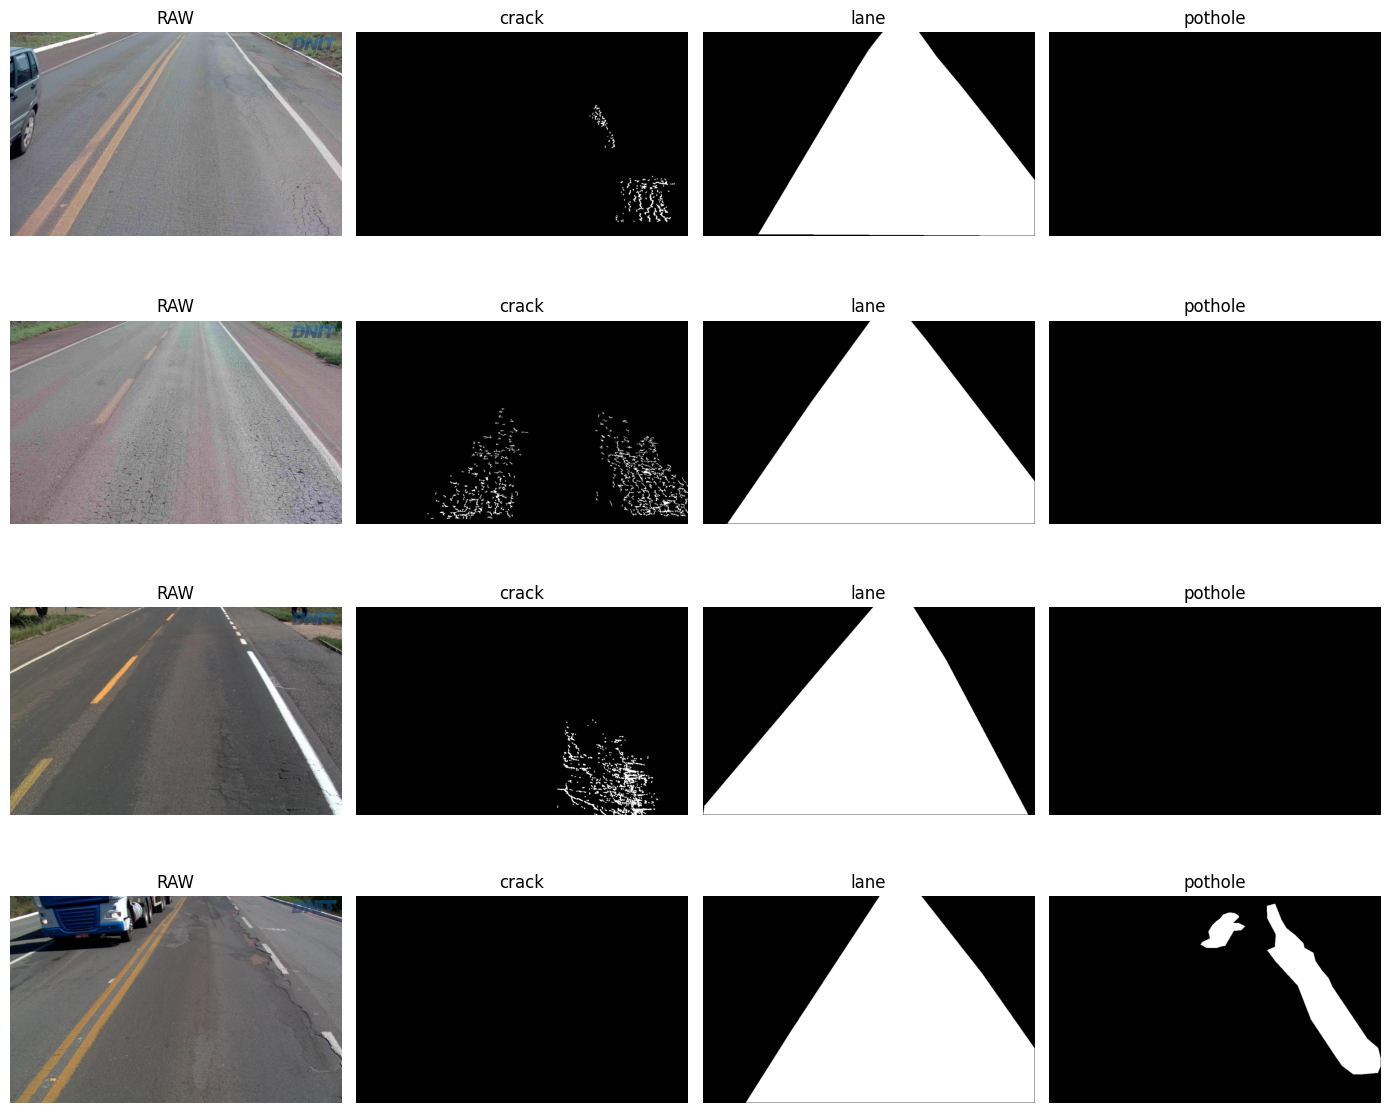

In [ ]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
pick = rng.choice(len(df), size=min(4, len(df)), replace=False)
fig, axes = plt.subplots(len(pick), 4, figsize=(14, 3 * len(pick)))
if len(pick) == 1:
    axes = np.expand_dims(axes, 0)
for row, i in enumerate(pick):
    r = df.iloc[int(i)]
    raw = np.asarray(Image.open(r["raw"]).convert("RGB"))
    axes[row, 0].imshow(raw)
    axes[row, 0].set_title("RAW")
    axes[row, 0].axis("off")
    for j, (title, col) in enumerate(
        [("crack", "crack_mask"), ("lane", "lane_mask"), ("pothole", "pothole_mask")],
        start=1,
    ):
        m = np.asarray(Image.open(r[col]).convert("L"))
        axes[row, j].imshow(m > 0, cmap="gray")
        axes[row, j].set_title(title)
        axes[row, j].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
raw_kb,2235.0,90.323755,18.375358,57.717773,78.737305,85.346680,92.440430,173.764648
crack_mask_kb,2235.0,9.736534,6.333982,2.920898,4.773926,8.430664,12.914551,49.568359
lane_mask_kb,2235.0,6.656129,0.142637,5.988281,6.544922,6.652344,6.813477,6.878906
pothole_mask_kb,2235.0,3.162512,0.663630,2.920898,2.920898,2.965820,3.005371,8.656250
width,2235.0,1024.000000,0.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
height,2235.0,635.489933,4.977052,630.000000,630.000000,640.000000,640.000000,640.000000
crack_fg_ratio,2235.0,0.009471,0.010326,0.000000,0.001950,0.006726,0.013480,0.086323
lane_fg_ratio,2235.0,0.556794,0.028455,0.464512,0.537386,0.554849,0.572028,0.727376
pothole_fg_ratio,2235.0,0.004088,0.015936,0.000000,0.000000,0.000000,0.000348,0.189319


## EDA por clase

In [ ]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from scipy import ndimage as ndi
from tqdm.auto import tqdm

need_base = ["sample_id", "raw", "crack_mask", "lane_mask", "pothole_mask"]
miss = [c for c in need_base if c not in df.columns]
if miss:
    raise RuntimeError("Faltan columnas en df: " + ", ".join(miss))

if "tipo_captura" not in df.columns:
    parts = df["sample_id"].str.split("_", n=3, expand=True)
    df["tipo_captura"] = parts[1]


def connected_components_stats(binary: np.ndarray) -> tuple[int, int, float, float]:
    fg = int(binary.sum())
    if fg == 0:
        return 0, 0, np.nan, np.nan
    labels, nlab = ndi.label(binary)
    if nlab == 0:
        return 0, fg, np.nan, np.nan
    sizes = np.bincount(labels.ravel())
    areas = sizes[1:]
    largest = int(areas.max())
    med = float(np.median(areas))
    largest_frac = largest / fg
    return int(nlab), fg, med, largest_frac


rows_long: list[dict] = []
overlap_rows: list[dict] = []

for _, r in tqdm(df.iterrows(), total=len(df), desc="EDA por clase"):
    sid = r["sample_id"]
    try:
        gray = np.asarray(Image.open(r["raw"]).convert("RGB"), dtype=np.float32).mean(axis=2)
        masks = {
            "crack": np.asarray(Image.open(r["crack_mask"]).convert("L")) > 0,
            "lane": np.asarray(Image.open(r["lane_mask"]).convert("L")) > 0,
            "pothole": np.asarray(Image.open(r["pothole_mask"]).convert("L")) > 0,
        }

        c, l, p = masks["crack"], masks["lane"], masks["pothole"]
        union_cl = np.logical_or(c, l)
        union_cp = np.logical_or(c, p)
        union_lp = np.logical_or(l, p)
        overlap_rows.append(
            {
                "sample_id": sid,
                "tipo_captura": r["tipo_captura"],
                "pair_crack_lane_inter": float(np.logical_and(c, l).mean()),
                "pair_crack_pothole_inter": float(np.logical_and(c, p).mean()),
                "pair_lane_pothole_inter": float(np.logical_and(l, p).mean()),
                "triple_inter": float(np.logical_and(np.logical_and(c, l), p).mean()),
                "iou_crack_lane": float(np.logical_and(c, l).sum() / union_cl.sum()) if union_cl.any() else 0.0,
                "iou_crack_pothole": float(np.logical_and(c, p).sum() / union_cp.sum()) if union_cp.any() else 0.0,
                "iou_lane_pothole": float(np.logical_and(l, p).sum() / union_lp.sum()) if union_lp.any() else 0.0,
            }
        )

        for cls_name, bin_mask in masks.items():
            n_cc, fg_px, cc_area_median, largest_frac = connected_components_stats(bin_mask)
            total_px = bin_mask.size
            fg_ratio = fg_px / total_px if total_px else 0.0
            empty = fg_px == 0

            mean_fg = np.nan
            std_fg = np.nan
            mean_bg = np.nan
            contrast = np.nan
            if not empty:
                vals = gray[bin_mask]
                bg = gray[~bin_mask]
                mean_fg = float(vals.mean())
                std_fg = float(vals.std())
                mean_bg = float(bg.mean())
                contrast = mean_fg - mean_bg

            rows_long.append(
                {
                    "sample_id": sid,
                    "tipo_captura": r["tipo_captura"],
                    "class": cls_name,
                    "fg_ratio": fg_ratio,
                    "fg_pixels": fg_px,
                    "empty_mask": empty,
                    "n_connected_components": n_cc,
                    "cc_area_median": cc_area_median,
                    "largest_cc_fg_fraction": largest_frac,
                    "gray_mean_fg": mean_fg,
                    "gray_std_fg": std_fg,
                    "gray_mean_bg": mean_bg,
                    "gray_contrast_fg_minus_bg": contrast,
                }
            )
    except Exception as e:
        warnings.warn(f"Muestra omitida {sid}: {e}")

eda_long = pd.DataFrame(rows_long)
eda_overlap = pd.DataFrame(overlap_rows)

print("Filas long-format (3 por muestra):", len(eda_long))
display(eda_long.groupby("class").agg(
    muestras=("sample_id", "nunique"),
    pct_mascara_vacia=("empty_mask", lambda s: 100 * s.mean()),
    fg_ratio=("fg_ratio", "median"),
    fg_ratio_p90=("fg_ratio", lambda s: s.quantile(0.9)),
    n_cc_mediana=("n_connected_components", "median"),
    n_cc_p90=("n_connected_components", lambda s: s.quantile(0.9)),
    mayor_cc_frac_fg_mediana=("largest_cc_fg_fraction", "median"),
    contraste_gris_mediana=("gray_contrast_fg_minus_bg", "median"),
).round(4))

print("\nSolapamiento entre clases (medianas en fracción de imagen / IoU):")
display(eda_overlap.drop(columns=["sample_id"]).groupby("tipo_captura").median(numeric_only=True).round(5))
print("Global (todas las muestras):")
display(eda_overlap.drop(columns=["sample_id"]).median(numeric_only=True).round(5))

EDA por clase:   0%|          | 0/2235 [00:00<?, ?it/s]

Filas long-format (3 por muestra): 6705


,muestras,pct_mascara_vacia,fg_ratio,fg_ratio_p90,n_cc_mediana,n_cc_p90,mayor_cc_frac_fg_mediana,contraste_gris_mediana
class,,,,,,,,
crack,2235,14.0492,0.0067,0.0217,164.0,560.6,0.0749,-24.7406
lane,2235,0.0000,0.5548,0.5949,1.0,1.0,1.0000,-2.8958
pothole,2235,74.7651,0.0000,0.0068,0.0,2.0,0.9818,-8.1618



Solapamiento entre clases (medianas en fracción de imagen / IoU):


,pair_crack_lane_inter,pair_crack_pothole_inter,pair_lane_pothole_inter,triple_inter,iou_crack_lane,iou_crack_pothole,iou_lane_pothole
tipo_captura,,,,,,,
DF,0.00760,0.0,0.0,0.0,0.01384,0.0,0.0
ES,0.00180,0.0,0.0,0.0,0.00295,0.0,0.0
RS,0.00606,0.0,0.0,0.0,0.01079,0.0,0.0


Global (todas las muestras):


pair_crack_lane_inter       0.00670
pair_crack_pothole_inter    0.00000
pair_lane_pothole_inter     0.00000
triple_inter                0.00000
iou_crack_lane              0.01189
iou_crack_pothole           0.00000
iou_lane_pothole            0.00000
dtype: float64

### Figuras por clase

Distribuciones de cobertura, fragmentacion y contraste gris

fg_ratio                                                          \
           count    mean     std     min     25%     50%     75%     max   
class                                                                      
crack     2235.0  0.0095  0.0103  0.0000  0.0020  0.0067  0.0135  0.0863   
lane      2235.0  0.5568  0.0285  0.4645  0.5374  0.5548  0.5720  0.7274   
pothole   2235.0  0.0041  0.0159  0.0000  0.0000  0.0000  0.0003  0.1893   

        n_connected_components            ... largest_cc_fg_fraction       \
                         count      mean  ...                    75%  max   
class                                     ...                               
crack                   2235.0  235.3678  ...                 0.1384  1.0   
lane                    2235.0    1.0036  ...                 1.0000  1.0   
pothole                 2235.0    0.6774  ...                 1.0000  1.0   

        gray_contrast_fg_minus_bg                                      \
                            count     mean      std      min      25%   
class                                                                   
crack                      1921.0 -23.6432  11.1153 -83.2347 -30.7264   
lane                       2235.0  -1.4678  13.4544 -48.1921 -12.4765   
pothole                     564.0  -8.3091  14.3577 -77.7310 -15.6787   

                                    
             50%      75%      max  
class                               
crack   -24.7406 -16.3319  25.2297  
lane     -2.8958   8.2292  45.5650  
pothole  -8.1618  -0.4374  43.1521  

[3 rows x 32 columns]

Correlación de fg_ratio entre clases (misma muestra):


class,crack,lane,pothole
class,,,
crack,1.000,-0.019,-0.189
lane,-0.019,1.000,-0.062
pothole,-0.189,-0.062,1.000


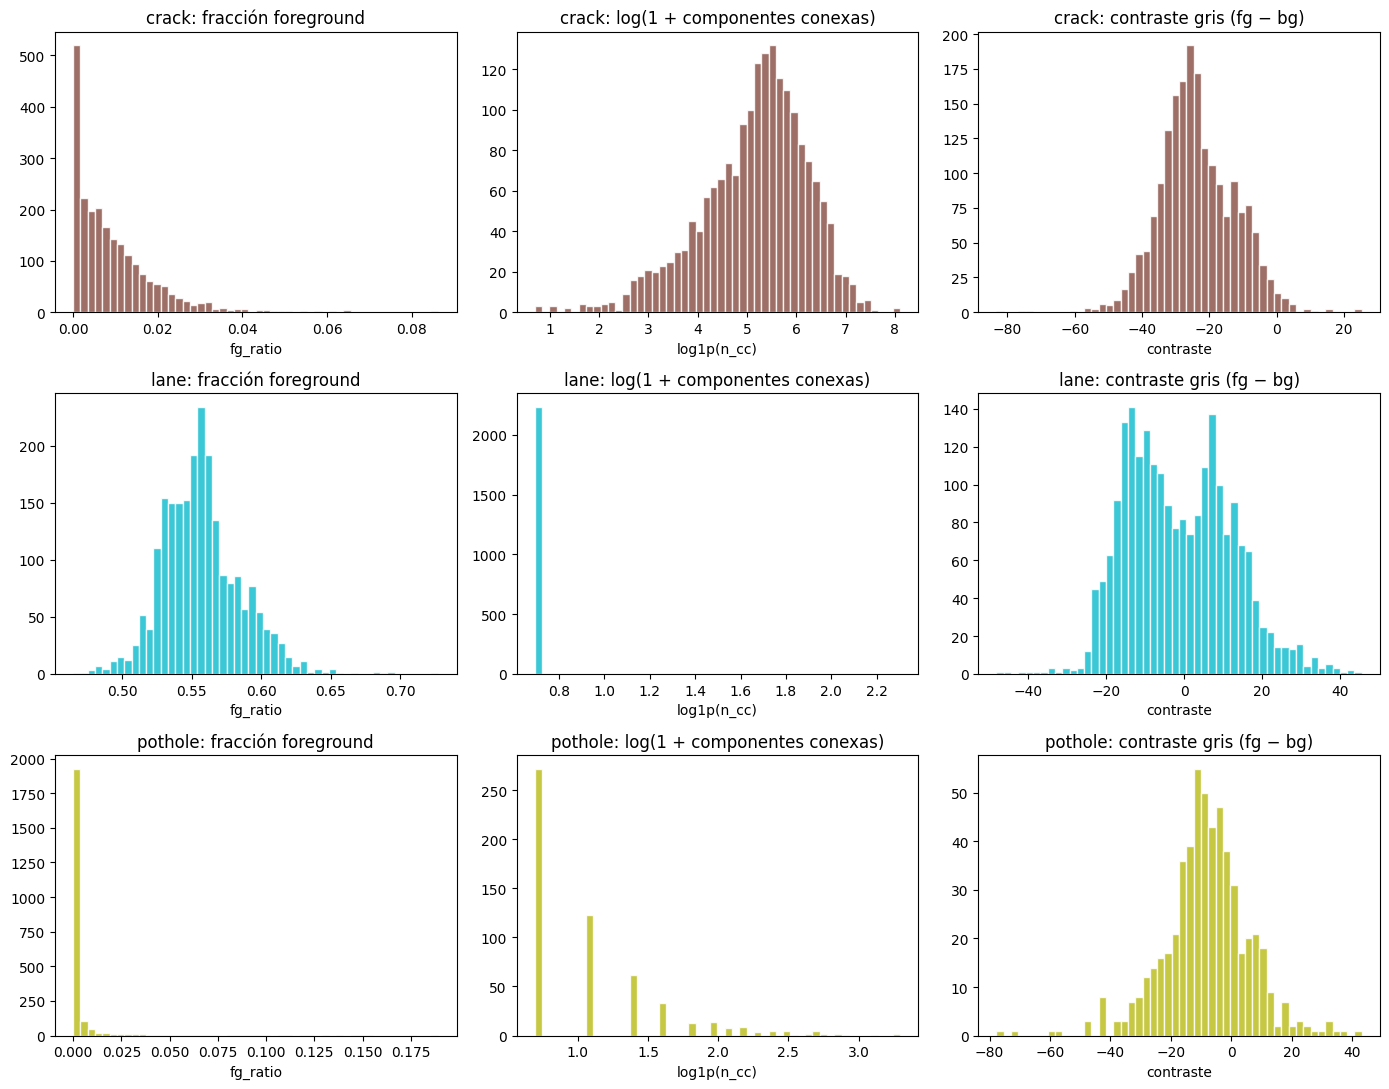

C:\Users\sebas\AppData\Local\Temp\ipykernel_21284\606452459.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2[i].boxplot(data, labels=[str(c) for c in cats])
C:\Users\sebas\AppData\Local\Temp\ipykernel_21284\606452459.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2[i].boxplot(data, labels=[str(c) for c in cats])
C:\Users\sebas\AppData\Local\Temp\ipykernel_21284\606452459.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2[i].boxplot(data, labels=[str(c) for c in cats])


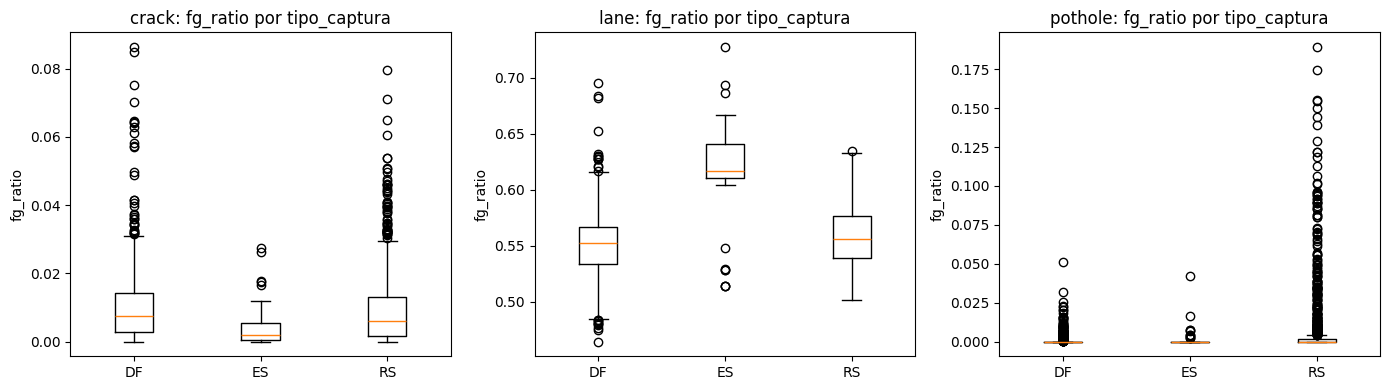

In [ ]:

numeric_cols = ["fg_ratio", "n_connected_components", "largest_cc_fg_fraction", "gray_contrast_fg_minus_bg"]
display(eda_long.groupby("class")[numeric_cols].describe().round(4))

wide_fg = eda_long.pivot_table(index="sample_id", columns="class", values="fg_ratio")
print("Correlación de fg_ratio entre clases (misma muestra):")
display(wide_fg.corr().round(3))

classes = ["crack", "lane", "pothole"]
colors = {"crack": "#8C564B", "lane": "#17BECF", "pothole": "#BCBD22"}

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for i, cls in enumerate(classes):
    sub = eda_long[eda_long["class"] == cls]
    axes[i, 0].hist(sub["fg_ratio"], bins=50, color=colors[cls], alpha=0.85, edgecolor="white")
    axes[i, 0].set_title(f"{cls}: fracción foreground")
    axes[i, 0].set_xlabel("fg_ratio")

    nn = sub.loc[~sub["empty_mask"], "n_connected_components"]
    if len(nn):
        axes[i, 1].hist(np.log1p(nn), bins=50, color=colors[cls], alpha=0.85, edgecolor="white")
    axes[i, 1].set_title(f"{cls}: log(1 + componentes conexas)")
    axes[i, 1].set_xlabel("log1p(n_cc)")

    ct = sub.loc[~sub["empty_mask"], "gray_contrast_fg_minus_bg"].dropna()
    if len(ct):
        axes[i, 2].hist(ct, bins=50, color=colors[cls], alpha=0.85, edgecolor="white")
    axes[i, 2].set_title(f"{cls}: contraste gris (fg − bg)")
    axes[i, 2].set_xlabel("contraste")

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(1, 3, figsize=(14, 4))
for i, cls in enumerate(classes):
    sub = eda_long[eda_long["class"] == cls]
    cats = sorted(sub["tipo_captura"].dropna().unique())
    data = [sub.loc[sub["tipo_captura"] == c, "fg_ratio"].values for c in cats]
    ax2[i].boxplot(data, labels=[str(c) for c in cats])
    ax2[i].set_title(f"{cls}: fg_ratio por tipo_captura")
    ax2[i].set_ylabel("fg_ratio")
plt.tight_layout()
plt.show()

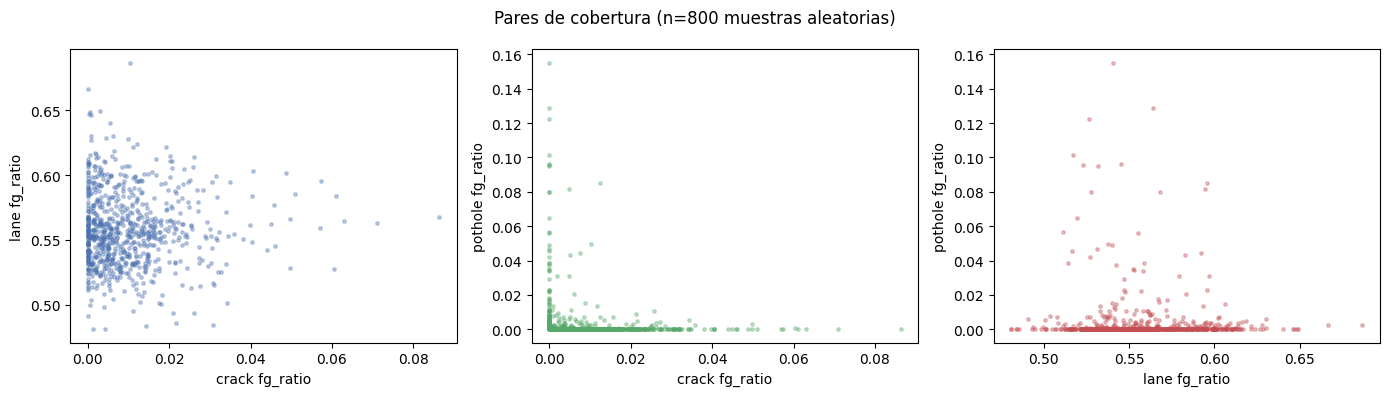

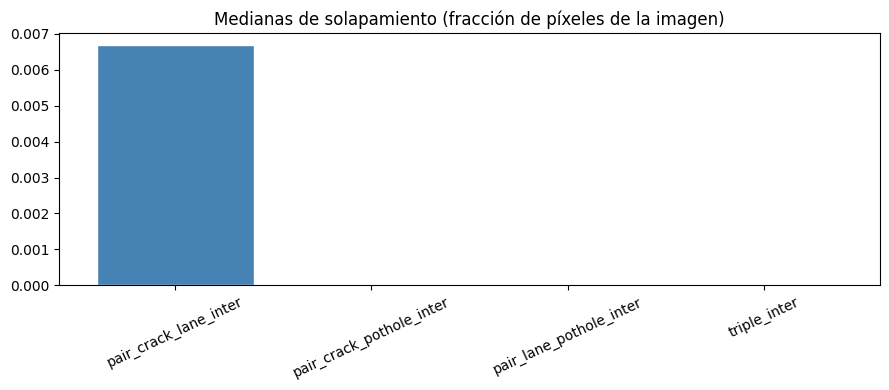

In [ ]:
sample_cap = min(800, len(wide_fg))
rs = wide_fg.sample(n=sample_cap, random_state=0).dropna(how="any")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(rs["crack"], rs["lane"], s=6, alpha=0.35, c="#4C72B0")
axes[0].set_xlabel("crack fg_ratio")
axes[0].set_ylabel("lane fg_ratio")

axes[1].scatter(rs["crack"], rs["pothole"], s=6, alpha=0.35, c="#55A868")
axes[1].set_xlabel("crack fg_ratio")
axes[1].set_ylabel("pothole fg_ratio")

axes[2].scatter(rs["lane"], rs["pothole"], s=6, alpha=0.35, c="#C44E52")
axes[2].set_xlabel("lane fg_ratio")
axes[2].set_ylabel("pothole fg_ratio")

plt.suptitle(f"Pares de cobertura (n={len(rs)} muestras aleatorias)")
plt.tight_layout()
plt.show()

ov_numeric = eda_overlap.drop(columns=["sample_id", "tipo_captura"]).median(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 4))
cols_show = [c for c in ov_numeric.index if c.startswith("pair") or c.startswith("triple")]
ax.bar(cols_show, ov_numeric[cols_show].values, color="steelblue", edgecolor="white")
ax.set_title("Medianas de solapamiento (fracción de píxeles de la imagen)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()